In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB

In [2]:
df = pd.read_csv(r"C:\Users\tanay\OneDrive\Desktop\datasets\Titanic-Dataset.csv")

In [3]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [6]:
nums = ['Age', 'SibSp','Parch'] #Fare
for i in nums:
    df[i] = df[i].fillna(df[i].median())

In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

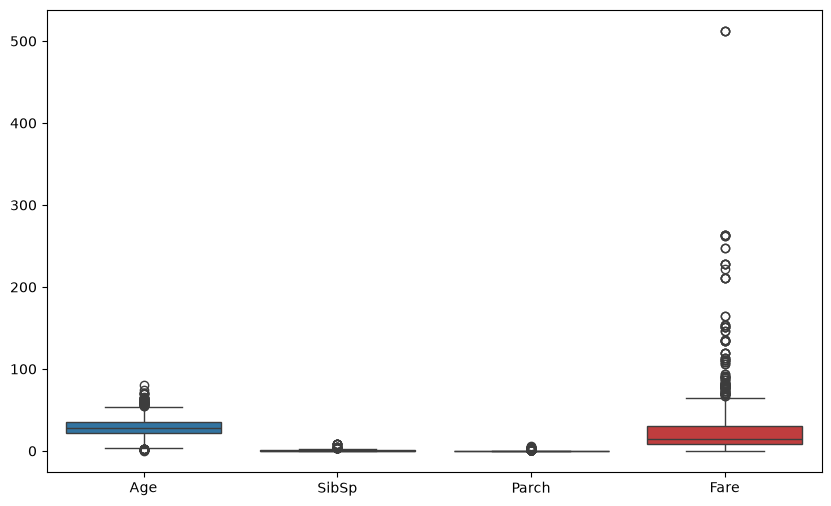

In [9]:
nums1 = ['Age', 'SibSp','Parch','Fare']
plt.figure(figsize = (10,6))
sns.boxplot(data = df[nums1])
plt.show()

In [17]:
for i in nums1:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*Q1
    upper = Q3 + 1.5*Q3
    median = df[i].median()
    df.loc[(df[i]<lower) | (df[i]>upper),i] = median
    
    

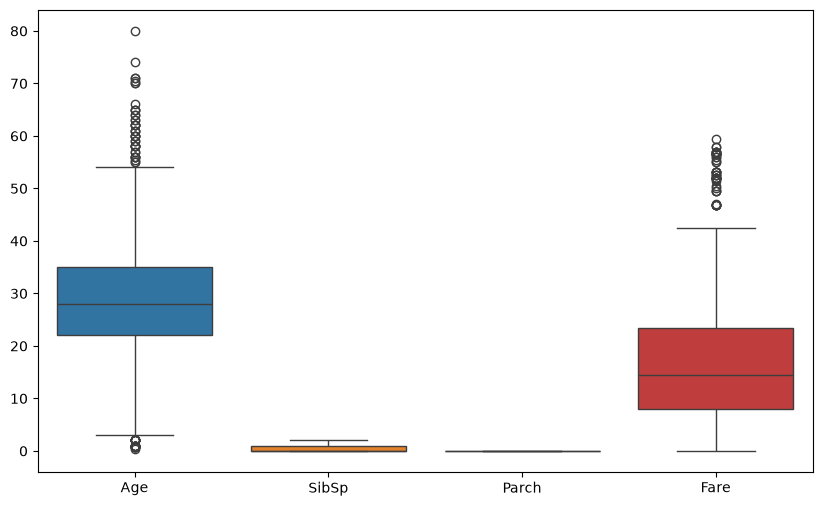

In [18]:
nums1 = ['Age', 'SibSp','Parch','Fare']
plt.figure(figsize = (10,6))
sns.boxplot(data = df[nums1])
plt.show()

In [20]:
df = pd.get_dummies(df,columns=["Sex"],drop_first = True)

In [21]:
x = df.drop(["PassengerId",	"Survived","Pclass","Name","Ticket","Cabin","Embarked"],axis=1)
y = df["Survived"]

In [22]:
print(x.shape)
print(y.shape)

(891, 5)
(891,)


In [24]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2, random_state = 42)
sc = StandardScaler()
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

In [25]:
gnb = GaussianNB()
gnb.fit(x_train_scaled,y_train)
y_pred = gnb.predict(x_test_scaled)

In [28]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
print("Accuracy score: ",accuracy_score(y_test,y_pred))
print("Recall Score: ",recall_score(y_test,y_pred))
print("Precision Score: ",precision_score(y_test,y_pred))

Accuracy score:  0.9162011173184358
Recall Score:  0.9032258064516129
Precision Score:  0.7


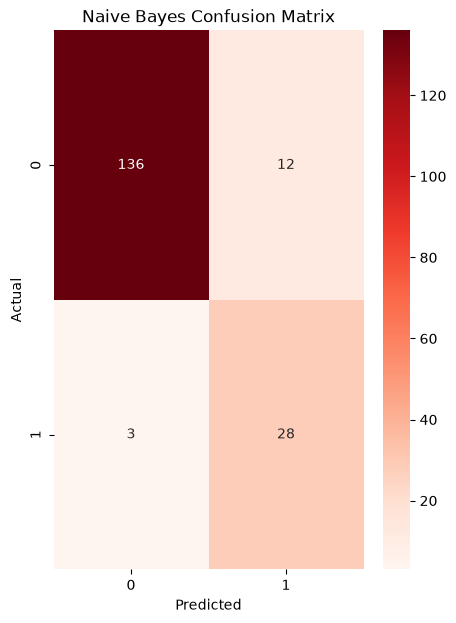

In [29]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,7))
sns.heatmap(cm,
annot=True,
fmt='d',
cmap='Reds'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")
plt.show()

In [31]:
print(y.value_counts())

Survived
0    766
1    125
Name: count, dtype: int64


In [34]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state = 42)
x_train_bal,y_train_bal = smote.fit_resample(x_train_scaled,y_train)

In [36]:
gnb2 = GaussianNB()
gnb2.fit(x_train_bal,y_train_bal)
y_pred_gn = gnb2.predict(x_test_scaled)

In [37]:
y_pred_gn

array([1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1])

In [38]:
print("Accuracy score: ",accuracy_score(y_test,y_pred_gn))
print("Recall Score: ",recall_score(y_test,y_pred_gn))
print("Precision Score: ",precision_score(y_test,y_pred_gn))

Accuracy score:  0.8938547486033519
Recall Score:  1.0
Precision Score:  0.62
